In [49]:
from lib.dataset_wrapper import Dataset

dataset = Dataset('pb2009')
items_cepstrum = dataset.get_items_data('mel_20ms', cut_silences=True, format='.npy')
items_source = dataset.get_items_data('source', cut_silences=True, format='.npy')
items_art_params = dataset.get_items_data('art_params', cut_silences=True, format='.npy')
items_lab = dataset._get_items_lab()

Transposing features to get [T,N] vectors.


In [51]:
for key, value in items_lab.items():
    print(key, len(value))

item_0001 5
item_0002 5
item_0003 5
item_0004 5
item_0005 5
item_0006 5
item_0007 5
item_0008 5
item_0009 5
item_0010 5
item_0011 5
item_0012 5
item_0013 5
item_0014 5
item_0015 5
item_0016 5
item_0017 5
item_0018 5
item_0019 5
item_0020 5
item_0021 5
item_0022 5
item_0023 5
item_0024 5
item_0025 5
item_0026 5
item_0027 5
item_0028 5
item_0029 5
item_0030 5
item_0031 5
item_0032 5
item_0033 5
item_0034 5
item_0035 5
item_0036 5
item_0037 5
item_0038 5
item_0039 5
item_0040 5
item_0041 5
item_0042 5
item_0043 5
item_0044 5
item_0045 5
item_0046 5
item_0047 5
item_0048 5
item_0049 5
item_0050 5
item_0051 5
item_0052 5
item_0053 5
item_0054 5
item_0055 5
item_0056 5
item_0057 5
item_0058 5
item_0059 5
item_0060 5
item_0061 5
item_0062 5
item_0063 5
item_0064 5
item_0065 5
item_0066 5
item_0067 5
item_0068 5
item_0069 5
item_0070 5
item_0071 5
item_0072 5
item_0073 5
item_0074 5
item_0075 5
item_0076 5
item_0077 5
item_0078 5
item_0079 5
item_0080 5
item_0081 5
item_0082 5
item_0083 5
item

7.199999999999999
6.0
4.8
3.5999999999999996
2.4
1.2


/tmp/ipykernel_18097/1642429888.py:70: UserWarning: This figure was using constrained_layout==True, but that is incompatible with subplots_adjust and or tight_layout: setting constrained_layout==False. 
  plt.tight_layout()


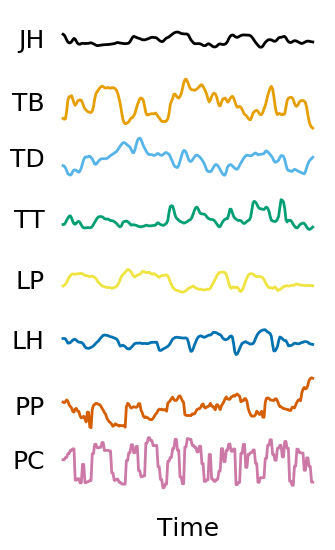

In [74]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.serif'] = 'Arial'
matplotlib.rcParams.update({'font.size': 18, 'legend.handleheight':1, 'hatch.linewidth': 1.0,
                           'lines.markersize':5, 'lines.linewidth':2, 'errorbar.capsize': 5})
item_name = 'item_1264'
art_params = items_art_params[item_name]
source = items_source[item_name]

def min_max_normalize(data):
    return (data - np.min(data)) / (np.max(data) - np.min(data))

source = np.apply_along_axis(min_max_normalize, 0, source)
art_params = min_max_normalize(art_params)

# Create time points for x-axis
time_points = np.arange(art_params.shape[0])

# Create color map for different features
labels = ['JH', 'TB', 'TD', 'TT', 'LP', 'LH', 'PP', 'PC']
colors = colors = ['#000000',  # Black
              '#E69F00',  # Orange
              '#56B4E9',  # Light blue
              '#009E73',  # Green
              '#F0E442',  # Yellow
              '#0072B2',  # Dark blue
              '#D55E00',  # Red
              '#CC79A7']  # Pink

# Calculate vertical spacing
# Assuming you want equal spacing between features
vertical_spacing = np.max(np.abs(art_params)) * 1.2

cm = 1/2.54
fig = plt.figure(figsize=(10.5*cm,18.04*cm), constrained_layout=True)

# Plot each feature with vertical offset
for i in range(6):
    # Add offset: multiply by (5-i) to plot from top to bottom
    offset =  vertical_spacing * (6 - i)
    data = art_params[:,i]
    plt.plot(time_points, data + offset, 
            color=colors[i])
    y = offset + np.mean(data)
    print(offset)
    plt.text(-15, y, labels[i], horizontalalignment='right', verticalalignment='center')

for i in range(2):
    offset = vertical_spacing * (-i)
    data = source[:,i]
    plt.plot(time_points, data + offset, 
            color=colors[i+6])
    y = offset + np.mean(data)
    plt.text(-15, y, labels[i+6], horizontalalignment='right', verticalalignment='center')
    
# Customize the plot
plt.xlabel('Time')
plt.gca().yaxis.set_visible(False)
plt.gca().xaxis.set_ticks([])
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)
plt.gca().spines['left'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Adjust layout to prevent legend cutoff
plt.savefig('/home/engaclew/agent/out/ssl_agent/input_synth.png', dpi=300)
plt.tight_layout()